<a href="https://colab.research.google.com/github/sardar-ammad-143/Basic-Python/blob/main/air%20quality%20model%20train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import necessary libraries
import pandas as pd  # For data manipulation
import numpy as np   # For numerical operations
import matplotlib.pyplot as plt  # For plotting
import seaborn as sns  # For visualizations
from sklearn.preprocessing import MinMaxScaler  # For normalization


In [4]:
# Load the dataset
file_path = "/content/sample_data/edited .csv"  # Replace with the actual file path
data = pd.read_csv(file_path)

# Display the first few rows of the dataset
print(data.head())


   PM2.5    PM10    NO    NO2    NOx    NH3   CO    SO2      O3  Benzene  \
0  60.50   98.00  2.35  30.80  18.25   8.50  0.1  11.85  126.40      0.1   
1  65.50  111.25  2.70  24.20  15.07   9.77  0.1  13.17  117.12      0.1   
2  80.00  132.00  2.10  25.18  15.15  12.02  0.1  12.08   98.98      0.2   
3  81.50  133.25  1.95  16.25  10.23  11.58  0.1  10.47  112.20      0.2   
4  75.25  116.00  1.43  17.48  10.43  12.03  0.1   9.12  106.35      0.2   

   Toluene  Xylene  AQI  
0     6.10    0.10  NaN  
1     6.25    0.15  NaN  
2     5.98    0.18  NaN  
3     6.72    0.10  NaN  
4     5.75    0.08  NaN  


In [5]:
# Check the shape of the dataset
print("Dataset Shape:", data.shape)

# Display basic information about the dataset
print(data.info())

# Check for missing values
print("Missing Values:\n", data.isnull().sum())


Dataset Shape: (1048575, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 13 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PM2.5    800186 non-null  float64
 1   PM10     705840 non-null  float64
 2   NO       817926 non-null  float64
 3   NO2      831443 non-null  float64
 4   NOx      855903 non-null  float64
 5   NH3      581798 non-null  float64
 6   CO       827526 non-null  float64
 7   SO2      664348 non-null  float64
 8   O3       798087 non-null  float64
 9   Benzene  701860 non-null  float64
 10  Toluene  672187 non-null  float64
 11  Xylene   213458 non-null  float64
 12  AQI      809031 non-null  float64
dtypes: float64(13)
memory usage: 104.0 MB
None
Missing Values:
 PM2.5      248389
PM10       342735
NO         230649
NO2        217132
NOx        192672
NH3        466777
CO         221049
SO2        384227
O3         250488
Benzene    346715
Toluene    376388
Xylene    

In [6]:
# Fill missing values with the mean of each column
data.fillna(data.mean(), inplace=True)


normalization

In [7]:
from sklearn.preprocessing import MinMaxScaler

# Apply Min-Max Normalization
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)
data = pd.DataFrame(data_normalized, columns=data.columns)


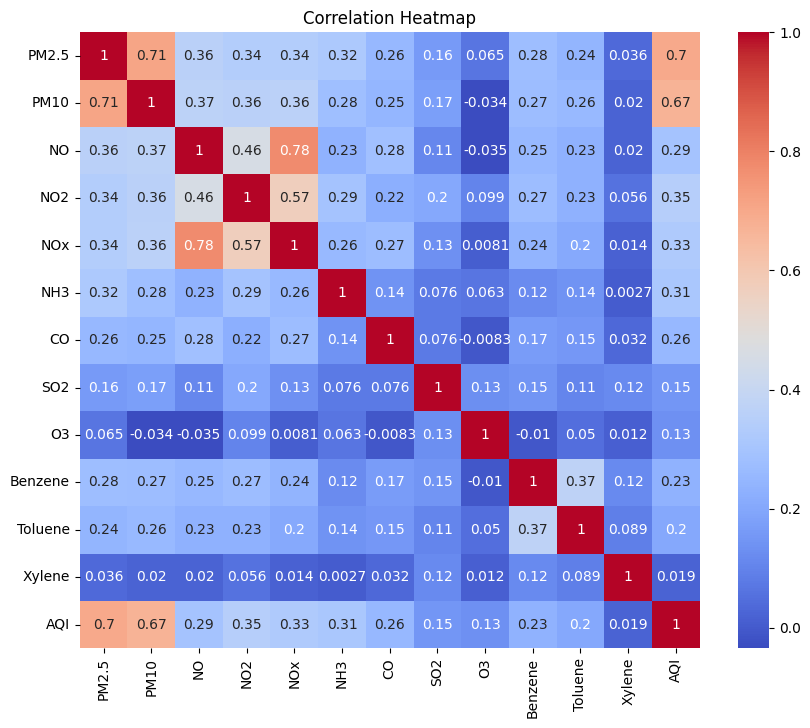

AQI        1.000000
PM2.5      0.699242
PM10       0.669111
NO2        0.345931
NOx        0.327542
NH3        0.312777
NO         0.293561
CO         0.256028
Benzene    0.233827
Toluene    0.202473
SO2        0.148343
O3         0.134900
Xylene     0.018605
Name: AQI, dtype: float64


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
correlation = data.corr()

# Visualize correlations with a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Check the correlation of each variable with AQI
correlation_with_aqi = correlation['AQI'].sort_values(ascending=False)
print(correlation_with_aqi)


In [9]:
# Drop variables with low correlation with AQI
columns_to_drop = ['Toluene', 'SO2', 'O3', 'Xylene']
data_selected = data.drop(columns=columns_to_drop)

# Display the updated dataset
print(data_selected.head())


      PM2.5      PM10       NO       NO2      NOx       NH3     CO   Benzene  \
0  0.060491  0.097991  0.00468  0.061585  0.03650  0.017183  0.002  0.000203   
1  0.065491  0.111241  0.00538  0.048384  0.03014  0.019753  0.002  0.000203   
2  0.079991  0.131991  0.00418  0.050344  0.03030  0.024307  0.002  0.000407   
3  0.081491  0.133241  0.00388  0.032483  0.02046  0.023416  0.002  0.000407   
4  0.075241  0.115991  0.00284  0.034943  0.02086  0.024327  0.002  0.000407   

      AQI  
0  0.1923  
1  0.1923  
2  0.1923  
3  0.1923  
4  0.1923  


In [10]:
from sklearn.preprocessing import MinMaxScaler


In [11]:
# Initialize Min-Max Scaler
scaler = MinMaxScaler()

# Select the features you want to scale (excluding 'AQI' if it's your target)
features_to_scale = ['PM2.5', 'PM10', 'NO2', 'NOx', 'NH3', 'NO', 'CO', 'Benzene']

# Apply scaling
data_scaled = data_selected.copy()
data_scaled[features_to_scale] = scaler.fit_transform(data_selected[features_to_scale])

# Display the normalized dataset
print(data_scaled.head())


      PM2.5      PM10       NO       NO2      NOx       NH3     CO   Benzene  \
0  0.060491  0.097991  0.00468  0.061585  0.03650  0.017183  0.002  0.000203   
1  0.065491  0.111241  0.00538  0.048384  0.03014  0.019753  0.002  0.000203   
2  0.079991  0.131991  0.00418  0.050344  0.03030  0.024307  0.002  0.000407   
3  0.081491  0.133241  0.00388  0.032483  0.02046  0.023416  0.002  0.000407   
4  0.075241  0.115991  0.00284  0.034943  0.02086  0.024327  0.002  0.000407   

      AQI  
0  0.1923  
1  0.1923  
2  0.1923  
3  0.1923  
4  0.1923  


In [12]:
# Check the min and max values of scaled features
print(data_scaled[features_to_scale].describe())


              PM2.5          PM10           NO2           NOx           NH3  \
count  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06   
mean   1.050068e-01  2.015118e-01  8.734935e-02  1.047844e-01  7.267093e-02   
std    8.860566e-02  1.283071e-01  7.018758e-02  1.237047e-01  4.071037e-02   
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    4.814048e-02  1.209912e-01  4.298344e-02  3.360000e-02  5.751872e-02   
50%    1.049910e-01  2.015118e-01  8.478678e-02  8.040000e-02  7.267093e-02   
75%    1.097411e-01  2.064821e-01  9.612769e-02  1.047844e-01  7.267093e-02   
max    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   

                 NO            CO       Benzene  
count  1.048575e+06  1.048575e+06  1.048575e+06  
mean   6.428135e-02  2.787330e-02  6.665879e-03  
std    1.062962e-01  3.760554e-02  1.038364e-02  
min    0.000000e+00  0.000000e+00  0.000000e+00  
25%    9.620192e-03  1.300000e-02  1.5

In [14]:
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# Assuming `data_scaled` is your dataframe and 'AQI' is the target variable

# Features and target variable
features_to_scale = ['PM2.5', 'PM10', 'NO2', 'NOx', 'NH3', 'NO', 'CO', 'Benzene']
X = data_scaled[features_to_scale]  # Independent variables
y = data_scaled['AQI']              # Target variable

# Scale the features (if not already scaled)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define the ANN model
model = Sequential()

# Input layer and first hidden layer
model.add(Dense(units=64, activation='relu', input_dim=X_train.shape[1]))

# Second hidden layer
model.add(Dense(units=32, activation='relu'))

# Output layer
model.add(Dense(units=1))  # Since we're predicting a continuous value (AQI)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Print model summary
model.summary()

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Save the model to a file
model.save('aqi_predictor_ann_model.h5')

# Save the scaler for future use (for scaling new data before prediction)
joblib.dump(scaler, 'scaler.pkl')

# Evaluate the model on the test data
test_loss = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss}')



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 50s 2ms/step - loss: 0.0052 - val_loss: 0.0041
Epoch 2/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - loss: 0.0041 - val_loss: 0.0040
Epoch 3/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 82s 2ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 4/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 85s 2ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 5/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 81s 2ms/step - loss: 0.0040 - val_loss: 0.0039
Epoch 6/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 49s 2ms/step - loss: 0.0039 - val_loss: 0.0039
Epoch 7/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 47s 2ms/step - loss: 0.0039 - val_loss: 0.0040
Epoch 8/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 84s 2ms/step - loss: 0.0039 - val_loss: 0.0039
Epoch 9/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - loss: 0.0039 - val_loss: 0.0040
Epoch 10/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - loss: 0.0039 - val_loss: 0.0039
Epoch 11/50
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 86s 2ms/step - loss: 0.0039 - val_loss: 0.00

6554/6554 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 0.0039
Test Loss: 0.003961823880672455


In [15]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Save the model in the recommended Keras format
model.save('aqi_predictor_model.keras')

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate R² (Coefficient of Determination)
r2 = r2_score(y_test, y_pred)

# Calculate MAE, MSE, and RMSE
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print evaluation metrics
print(f"R²: {r2 * 100:.2f}%")  # Convert to percentage
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


6554/6554 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
R²: 65.27%
Mean Absolute Error (MAE): 0.0437
Mean Squared Error (MSE): 0.0040
Root Mean Squared Error (RMSE): 0.0629
